# Цифровые технологии в профессиональной деятельности
## Раздел 1. Текст-майнинг
## Семинар 2. Культуромика

На первом семинаре мы повторили **предобработку текста**: токенизацию, лемматизацию, подсчёт частотности. 

Второй семинар мы посвятим работе с корпусом Посланий Федеральному собранию и перейдём к **культуромике** — количественному анализу культурных и социальных процессов посредством текстовых данных.

**План:**
1. Проводим мини-исследование на текстах Посланий Президента РФ к Федеральному собранию: нормализация, концепты, маркеры, n-граммы, TTR.
2. TF-IDF — выделяем ключевые слова периода.

### Подготовка: загружаем данные и повторяем первый семинар

Ниже — код из первого семинара, который формирует корпус и таблицу лемм. Его нужно просто запустить.

In [1]:
# импортируем библиотеки
import requests
import regex as re
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import pymorphy3
from razdel import tokenize
from collections import Counter
from nltk.corpus import stopwords
from string import punctuation
import nltk
import json
from wordcloud import WordCloud

# догружаем стоп-слова, дополняем их теми же словами, которые мы предложили на первом занятии
nltk.download('stopwords', quiet=True)
stop_words = set(stopwords.words('russian'))
stop_words.update(['который', 'это', 'наш', 'свой', 'быть', 'мочь', 'весь', 'всё',
                   'год', 'ещё', 'аплодисменты', 'должный', 'нужно', 'необходимо',
                   'вчера', 'также', 'важный', 'стать', 'сделать', 'сегодня'])

punctuation = punctuation + '«»—„“–'

stop_words.update(punctuation)

# запускаем морфологический парсер pymorphy3
morph = pymorphy3.MorphAnalyzer()

In [2]:
# Загрузка корпуса Посланий
urls = [
    r"https://raw.githubusercontent.com/always1ready/dh-tools/refs/heads/main/data/02_seminar/federal_assembly_address_1994.txt",
    r"https://raw.githubusercontent.com/always1ready/dh-tools/refs/heads/main/data/02_seminar/federal_assembly_address_1998.txt",
    r"https://raw.githubusercontent.com/always1ready/dh-tools/refs/heads/main/data/02_seminar/federal_assembly_address_2002.txt",
    r"https://raw.githubusercontent.com/always1ready/dh-tools/refs/heads/main/data/02_seminar/federal_assembly_address_2006.txt",
    r"https://raw.githubusercontent.com/always1ready/dh-tools/refs/heads/main/data/02_seminar/federal_assembly_address_2010.txt",
    r"https://raw.githubusercontent.com/always1ready/dh-tools/refs/heads/main/data/02_seminar/federal_assembly_address_2014.txt",
    r"https://raw.githubusercontent.com/always1ready/dh-tools/refs/heads/main/data/02_seminar/federal_assembly_address_2018.txt",
    r"https://raw.githubusercontent.com/always1ready/dh-tools/refs/heads/main/data/02_seminar/federal_assembly_address_2024.txt",
]

corpus = {}
for url in urls:
    year = re.search('\d{4}', url).group()
    response = requests.get(url)
    corpus[year] = response.text

print(f'Загружено {len(corpus)} текстов: {list(corpus.keys())}')

<>:15: SyntaxWarning: invalid escape sequence '\d'
<>:15: SyntaxWarning: invalid escape sequence '\d'
C:\Users\MSI\AppData\Local\Temp\ipykernel_1676\800070669.py:15: SyntaxWarning: invalid escape sequence '\d'
  year = re.search('\d{4}', url).group()


Загружено 8 текстов: ['1994', '1998', '2002', '2006', '2010', '2014', '2018', '2024']


In [3]:
# Лемматизация корпуса
def process_corpus(corpus_dict):
    full_results = {}
    for year, text in corpus_dict.items():
        tokens = [s.text.lower() for s in tokenize(text)]
        lemmas = []
        for word in tokens:
            lemma = morph.parse(word)[0].normal_form
            if lemma not in stop_words:
                lemmas.append(lemma)
        full_results[year] = Counter(lemmas)
    return full_results

final_counts = process_corpus(corpus)
print(f'Обработано {len(final_counts)} текстов')
print(f'Лемм в 1994: {len(final_counts["1994"])}, в 2024: {len(final_counts["2024"])}')

Обработано 8 текстов
Лемм в 1994: 2837, в 2024: 2603


Давайте превратим наши данные в DataFrame, чтобы сравнить тексты Посланий разных лет статистически.

`Counter()` - это словарь. Чтобы превратить словарь в таблицу, мы используем его метод `.items()`, который превращает словарь в список пар вида «слово — число». 

Когда мы передаем словарь в функцию `pd.DataFrame()`, библиотека `pandas` просто берет каждую такую пару и кладет её в отдельную строчку: первое значение из пары (ключ) отправляется в левую колонку, а второе (значение) — в правую.

Обратите внимание на левый столбик с цифрами — индексами. `Pandas` добавляет их автоматически, это его отличительная особенность (которая иногда приносит много хлопот).

In [4]:
planets = {
    'Земля' : '12 742',
    'Марс' : '6 779',
    'Юпитер' : '139 820',
    'Сатурн' : '116 460',
}

# Мы передаем список пар (planets.items()) и сразу называем колонки.
pd.DataFrame(planets.items(), columns=['Планета', 'Диаметр (км)'])

,Планета,Диаметр (км)
0,Земля,12 742
1,Марс,6 779
2,Юпитер,139 820
3,Сатурн,116 460


Но у нас в переменной **словарь** словарей, причём с частично совпадающим набором ключей. 

Чему будут соответствовать элементы словаря верхнего уровня и чему элементы вложенного словаря?

In [5]:
df = pd.DataFrame(final_counts).fillna(0).astype(int)
df.head(10)

,1994,1998,2002,2006,2010,2014,2018,2024
послание,11,11,4,11,7,6,35,8
президент,26,16,3,3,4,4,34,3
федеральный,87,79,23,9,9,6,35,31
собрание,23,14,10,5,2,2,32,4
укрепление,27,9,3,5,4,0,5,1
российский,108,52,22,15,10,10,24,21
государство,134,55,17,17,13,12,13,18
основной,11,6,0,4,1,2,0,4
направление,20,23,2,10,5,4,4,14
внутренний,11,14,0,4,0,5,1,6


---
## Часть 1. Культуромика на «малых данных»

### 1.1. Относительные частоты (нормализация)

Сравнивать абсолютные частоты слов между текстами разного объёма некорректно: в длинном тексте любое слово встретится чаще просто потому, что текст длиннее. Чтобы сравнение стало научным, мы переходим к **относительным частотам**.

Формула: `(Количество слова / Общее количество слов) * 1000`

В больших корпусах используется показатель **IPM** (items per million) — вхождений на миллион словоформ. Это стандартная единица в корпусной лингвистике, которую использует и Бонч-Осмоловская в разбираемой статье.

In [6]:
# Считаем общее количество лемм для каждого года
total_words_per_year = df.sum(axis=0)
print("Общее количество лемм по годам:")
print(total_words_per_year)

Общее количество лемм по годам:
1994    11234
1998    10249
2002     3661
2006     4142
2010     4481
2014     4226
2018     8219
2024     8092
dtype: int64


In [7]:
# Нормализуем: частота на 1000 слов
df_rel = (df / total_words_per_year) * 1000

# Округлим для удобства до 1 знака после запятой
df_rel = df_rel.round(1)

print("Таблица относительных частот (на 1000 слов):")
df_rel.sort_values(by='2024', ascending=False).head(10)

Таблица относительных частот (на 1000 слов):


,1994,1998,2002,2006,2010,2014,2018,2024
россия,11.9,7.6,9.6,8.0,4.7,14.0,11.9,9.4
проект,0.5,1.0,1.6,2.7,2.2,2.4,2.2,6.7
страна,4.9,6.2,10.4,8.2,4.9,5.7,7.9,6.2
рубль,0.3,0.5,0.3,4.6,1.8,1.7,1.2,6.2
программа,2.0,2.0,0.8,3.6,2.9,2.4,1.7,6.1
развитие,3.9,3.2,4.4,6.5,4.0,5.4,6.7,6.1
человек,4.5,2.0,2.7,3.9,4.9,6.6,6.9,6.1
регион,3.9,2.6,2.2,1.2,4.0,3.8,1.6,5.9
семья,0.2,0.3,0.3,3.9,3.8,0.7,2.1,5.8
новый,5.5,4.7,4.9,5.6,8.3,3.3,9.2,4.9


#### Задание 1
Выведите 10 самых частотных лемм **по всем Посланиям суммарно** (сумма нормализованных частот по строке).

Подсказка: используйте `.sum(axis=1)` и `.sort_values()`.

In [8]:
# ВАШ КОД

print("\nТаблица наиболее частотных лемм (нормированная)")



Таблица наиболее частотных лемм (нормированная)


### 1.2. Сравнительный анализ концептов

Относительные частоты позволяют увидеть «вес» идеи в тексте. Выберем слова, отражающие разные направления государственной политики.

In [9]:
# Убираем неинформативные слова
df_rel = df_rel[~df_rel.index.isin(stop_words)]

# Выбираем слова для анализа
target_words = ['свобода', 'безопасность', 'стабильность', 'семья', 'демократия']

dynamic_df = df_rel.reindex(target_words).fillna(0)
print("Динамика выбранных слов (частота на 1000 слов):")
display(dynamic_df)

Динамика выбранных слов (частота на 1000 слов):


,1994,1998,2002,2006,2010,2014,2018,2024
свобода,2.4,0.4,1.4,0.5,0.4,2.4,0.5,0.1
безопасность,2.9,0.8,1.4,1.7,1.6,2.1,1.5,1.1
стабильность,0.5,0.4,1.9,1.0,0.0,0.5,0.5,0.5
семья,0.2,0.3,0.3,3.9,3.8,0.7,2.1,5.8
демократия,1.0,0.4,0.0,0.5,0.4,0.2,0.2,0.1


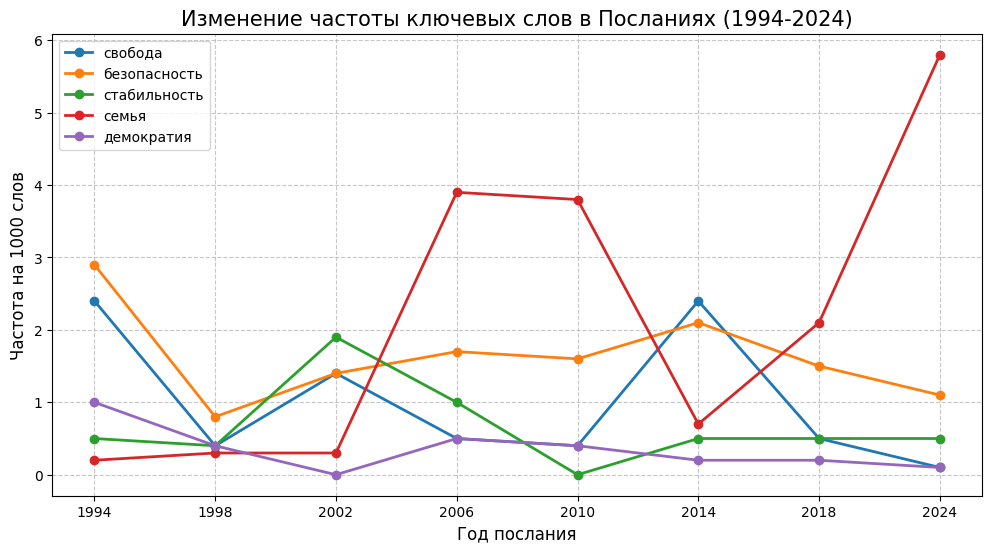

In [10]:
# ВИЗУАЛИЗАЦИЯ: ЛИНЕЙНЫЙ ГРАФИК
#
# matplotlib работает как холст: мы создаём фигуру, наносим на неё элементы
# (линии, подписи, сетку), а потом показываем результат.

# 1. Создаём фигуру (холст) заданного размера.
#    figsize=(ширина, высота) — в дюймах. 
#    12×6 — широкий горизонтальный график.
plt.figure(figsize=(12, 6))

# 2. Рисуем линию для каждого слова.
#    plt.plot(x, y) — основная функция для линейных графиков.
#    x = dynamic_df.columns — годы (ось X)
#    y = dynamic_df.loc[word] — частоты слова по годам (ось Y)
#    marker='o' — точки на линии (кружки); другие варианты: 's' (квадрат), '^' (треугольник)
#    label=word — подпись для легенды
#    linewidth=2 — толщина линии в пунктах
for word in target_words:
    plt.plot(dynamic_df.columns, dynamic_df.loc[word], marker='o', label=word, linewidth=2)

# 3. Оформление.
#    plt.title() — заголовок графика; fontsize — размер шрифта
plt.title('Изменение частоты ключевых слов в Посланиях (1994-2024)', fontsize=15)

#    plt.xlabel() / plt.ylabel() — подписи осей
plt.xlabel('Год послания', fontsize=12)
plt.ylabel('Частота на 1000 слов', fontsize=12)

#    plt.legend() — показывает легенду (какая линия какому слову соответствует).
#    Берёт значения из параметра label= в plt.plot()
plt.legend()

#    plt.grid() — сетка для удобства чтения.
#    linestyle='--' — пунктирная линия; alpha=0.7 — полупрозрачность (0 = невидимо, 1 = непрозрачно)
plt.grid(True, linestyle='--', alpha=0.7)

# 4. Показываем график. В Jupyter это необязательно (рисуется автоматически),
#    но plt.show() гарантирует, что график отобразится и «закроется» —
#    следующий plt.figure() начнёт новый холст, а не дорисует на этом.
plt.show()

#### Задание 2
Выберите **свои 5 слов** (концептов, которые вам интересны) и постройте аналогичный график. Отправьте результат в телеграм чат.

In [11]:
# ВАШ КОД
my_words = [...]  # впишите свои слова


### 1.3. Слова-маркеры периодов

Слова-маркеры — это леммы, которые встречаются **только в одном году** и отсутствуют в остальных. Они часто отражают конкретные политические события или приоритеты.

In [12]:
# Пример для 1994 года
target = '1994'

# Создаём датафрейм без столбца со значениями выбранного года
other_years = df_rel.columns.drop(target)

# Создаём условие-маску: суммируем значения по строкам и в качестве условия выводим только строки, равные нулю
unique_mask = df_rel[other_years].sum(axis=1) == 0

unique = df_rel[unique_mask][target].sort_values(ascending=False)

print(f"Слова-маркеры {target} года:")
print(unique.head(15))

Слова-маркеры 1994 года:
противоречие       0.9
религиозный        0.8
1993               0.8
межнациональный    0.7
национальность     0.6
меньшинство        0.6
наносить           0.5
сбс                0.5
имущественный      0.4
госбюджет          0.4
церковь            0.4
1994—1995          0.4
тоталитарный       0.4
безработица        0.4
неукоснительно     0.4
Name: 1994, dtype: float64


#### Задание 3
Напишите цикл, который найдёт слова-маркеры **для каждого года** и сохранит их в словарь `markers`.

In [13]:
# ВАШ КОД
markers = {}

# подсказка: перебирайте df_rel.columns


In [14]:
# ВИЗУАЛИЗАЦИЯ: ОБЛАКО СЛОВ (WordCloud)
#
# WordCloud — это не часть matplotlib, а отдельная библиотека,
# которая генерирует изображение-облако, а matplotlib просто показывает его.

# 1. Берём данные: словарь {слово: частота}
#    markers — это словарь, который мы получили в задании 3
data = markers.get('2024')

# 2. Создаём объект WordCloud с настройками внешнего вида.
#    width, height — размер изображения в пикселях
#    background_color — цвет фона ('white', 'black', или hex-код '#f0f0f0')
#    colormap — цветовая палитра из matplotlib. Варианты:
#      'viridis' (зелёно-жёлтая), 'plasma' (розово-жёлтая),
#      'coolwarm' (сине-красная), 'Set2' (пастельная), 'Dark2' (контрастная)
#    Полный список: https://matplotlib.org/stable/gallery/color/colormap_reference.html
wordcloud = WordCloud(
    width=800, 
    height=400, 
    background_color='white',
    colormap='viridis'
).generate_from_frequencies(data)
#    .generate_from_frequencies() принимает словарь {слово: число}.
#    Чем больше число, тем крупнее слово в облаке.
#    Альтернатива: .generate(text) — принимает строку и сам считает частоты.

# 3. Показываем облако через matplotlib.
#    plt.imshow() — функция для показа изображений (image show).
#    interpolation='bilinear' — сглаживание краёв букв. 
#    Без него текст будет пиксельным.
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')

#    plt.axis('off') — убираем оси (числовые подписи по краям).
#    Для облака слов оси не имеют смысла.
plt.axis('off')

plt.title('Маркеры Послания 2024 года', fontsize=15)
plt.show()

AttributeError: 'NoneType' object has no attribute 'items'

#### Задание 4

Выберите понравившийся вам год, сделайте собственное облако. Обязательно измените внешний вид, размер, поиграйте с параметрами. Отправьте результат в телеграм чат!

In [ ]:
# ВАШ КОД


## 1.4. Биграммы

Часто смысл текста заложен не в отдельных словах, а в их устойчивых сочетаниях. Для их поиска мы используем концепцию N-грамм — последовательностей из $n$ элементов.
* Биграммы ($n=2$) позволяют увидеть устойчивые пары (например, «рыночная экономика», «социальная сфера»).
* Триграммы ($n=3$) помогают выявить более сложные идеологемы (например, «великая отечественная война»).

Мы будем строить N-граммы на основе лемматизированного текста. Это позволит нам объединить разные формы одного и того же сочетания (например, «новым проектам» и «нового проекта») в одну сущность, что значительно повысит точность нашего частотного анализа.

In [23]:
tokens = ["this", "is", "a", "test", "don't", "panic", "u", "are", "the", "best", "students"]
n = 2

In [24]:
print('Первый тест')
for i in range(len(tokens)):
    x = " ".join(tokens[i:i+n])
    print(x)

Первый тест
this is
is a
a test
test don't
don't panic
panic u
u are
are the
the best
best students
students


In [25]:
print('Второй тест')
for i in range(len(tokens)-n):
    x = " ".join(tokens[i:i+n])
    print(x)

Второй тест
this is
is a
a test
test don't
don't panic
panic u
u are
are the
the best


In [27]:
print('Третий тест')
for i in range(len(tokens)-(n-1)):
    x = " ".join(tokens[i:i+n])
    print(x)

Третий тест
this is
is a
a test
test don't
don't panic
panic u
u are
are the
the best
best students


In [30]:
print('Четвёртый тест')
for i in range(len(tokens)-(n-1)):
    x = " ".join(tokens[i])
    print(x)

Четвёртый тест
t h i s
i s
a
t e s t
d o n ' t
p a n i c
u
a r e
t h e
b e s t


In [ ]:
# from collections import Counter
# import pandas as pd

def generate_ngrams(tokens, n):
    # Мы соединяем слова через пробел для наглядности
    return [" ".join(tokens[i:i+n]) for i in range(len(tokens)-(n-1))]

`range(len(tokens)-(n-1))` — центральная часть функции. Когда мы идем по списку слов «окном» определенного размера, мы должны остановиться чуть раньше конца списка, чтобы это окно не «вывалилось» за его пределы. 

Например, если у нас 10 слов и мы ищем триграммы ($n=3$), наше последнее окно начнется на 8-м слове и захватит 8-е, 9-е и 10-е. Если мы попробуем начать окно на 9-м слове, нам просто не хватит элементов для полноценной цепочки. Формула -(n-1) как раз гарантирует, что цикл завершится ровно тогда, когда для последнего окна еще хватает слов.

`tokens[i:i+n]` — механизм среза. На каждой итерации цикла переменная i указывает на начало окна, а i+n — на его конец.

`" ".join(...)` — срезы возвращают списки слов, например `['социальная', 'сфера']`. Работать с нагромождением мелких списков неудобно, поэтому мы превращаем их в обычные строки, склеивая слова через пробел.

In [ ]:
# В разделе 1.1 нам нужны были счётчики (Counter) — сколько раз встретилось каждое слово.
# Для биграмм нужны списки лемм, потому что порядок слов важен:
# Counter({'дорога': 5, 'железный': 3}) не хранит информацию о том,
# что «железный» стоял перед «дорога». А список ['железный', 'дорога', ...] — хранит.

def tokenize_corpus(corpus_dict):
    results = {}
    for year, text in corpus_dict.items():
        tokens = [s.text.lower() for s in tokenize(text)]
        lemmas = [morph.parse(t)[0].normal_form for t in tokens
                  if morph.parse(t)[0].normal_form not in stop_words]
        results[year] = lemmas
    return results

texts_by_year = tokenize_corpus(corpus)

In [ ]:
all_years_bigrams = {}

for year in ['1994', '1998', '2002', '2006', '2010', '2014', '2018', '2024']:
    year_lemmas = texts_by_year[year] 
    
    # Генерируем биграммы
    year_bigrams = generate_ngrams(year_lemmas, 2)
    
    # Считаем их и сохраняем в словарь
    all_years_bigrams[year] = Counter(year_bigrams)

# 2. Создаем общий DataFrame
df_ngrams = pd.DataFrame(all_years_bigrams)

# 3. Заполняем пустоты нулями (если биграмма была в 2024, но не в 1994)
df_ngrams = df_ngrams.fillna(0).astype(int).sort_values(by='1994', ascending=False)

df_ngrams.head(15)

Теперь найдём биграммы-маркеры — устойчивые пары слов, характерные **только для одного года**. Используем тот же приём, что и для отдельных лемм в разделе 1.3: ищем строки, у которых сумма по всем остальным годам равна нулю.

In [ ]:
bi_markers = {}

for year in df_ngrams.columns:
    target = year
    other_years = df_ngrams.columns.drop(target)
    unique_lemmas_mask = df_ngrams[other_years].sum(axis=1) == 0
    unique = df_ngrams[unique_lemmas_mask][target].sort_values(ascending=False)
    bi_markers[year] = unique

In [ ]:
# Облако слов для биграмм-маркеров — тот же принцип, что и выше.
# Разница только в данных: вместо отдельных лемм — пары слов.
data = bi_markers.get('2024')

wordcloud = WordCloud(
    width=800, 
    height=400, 
    background_color='white',
    colormap='viridis'
).generate_from_frequencies(data)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Биграммы-маркеры Послания 2024 года', fontsize=15)
plt.show()

## 1.5 Оценка лексического разнообразия
Стал ли язык официальных обращений более сухим и шаблонным за последние 30 лет? Чтобы ответить на этот вопрос, мы вычислим коэффициент **TTR (Type-Token Ratio)**.

**TTR = (Число уникальных лемм / Общее число лемм) * 100%**

*Высокий TTR* говорит о богатом словарном запасе и низкой повторяемости слов. 
*Низкий TTR* указывает на обилие речевых штампов и повторов.

In [16]:
ttr_results = {}

for year in df.columns:
    # Общее количество слов (сумма по столбцу)
    total_tokens = df[year].sum()
    
    # Количество уникальных слов (где частота > 0)
    unique_types = len(df[df[year] > 0])
    
    # Считаем TTR в процентах
    ttr = (unique_types / total_tokens) * 100
    ttr_results[year] = round(ttr, 2)

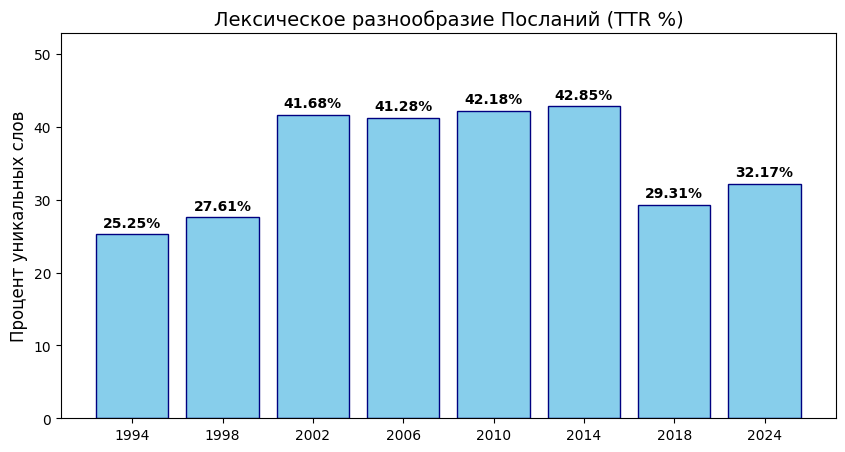

In [17]:
# ВИЗУАЛИЗАЦИЯ: СТОЛБЧАТАЯ ДИАГРАММА
#
# plt.bar() вместо plt.plot() — столбцы вместо линий.
# Используется, когда нужно сравнить значения по категориям (годам).

# Подготовка данных: словарь -> два списка (для осей X и Y)
years = list(ttr_results.keys())    # ['1994', '1998', ...]
values = list(ttr_results.values())  # [34.2, 28.5, ...]

# Создаём холст
plt.figure(figsize=(10, 5))

# plt.bar(x, y) — рисует столбцы.
#   color='skyblue' — цвет заливки столбцов
#   edgecolor='navy' — цвет обводки столбцов
plt.bar(years, values, color='skyblue', edgecolor='navy')

# Заголовок и подпись оси Y
plt.title('Лексическое разнообразие Посланий (TTR %)', fontsize=14)
plt.ylabel('Процент уникальных слов', fontsize=12)

# plt.ylim(min, max) — задаёт диапазон оси Y вручную.
# Без этого matplotlib подберёт диапазон автоматически,
# но мы хотим запас сверху для подписей.
plt.ylim(0, max(values) + 10)

# Добавляем подписи значений над каждым столбцом.
# enumerate(values) даёт пары (индекс, значение): (0, 34.2), (1, 28.5), ...
# plt.text(x, y, текст) — рисует текст в точке (x, y).
#   ha='center' — horizontal alignment, текст по центру столбца
#   fontweight='bold' — жирный шрифт
for i, v in enumerate(values):
    plt.text(i, v + 1, f"{v}%", ha='center', fontweight='bold')

plt.show()

#### Вопрос для размышления

Как вы думаете, почему TTR меняется от года к году? Это связано с длиной текста (чем длиннее текст, тем ниже TTR — слова начинают повторяться), с политической ситуацией, со стилем конкретного президента или с чем-то ещё? Обсудим.

In [ ]:
import math

N = len(df.columns)  # число документов (Посланий)
print(f'Всего документов: {N}')
print()

for word in ['демократия', 'государство', 'крым']:
    if word not in df.index:
        print(f'«{word}»: не найдено в корпусе')
        continue
    
    # DF = в скольких годах слово встречается хотя бы раз
    document_freq = (df.loc[word] > 0).sum()
    
    # IDF = log(N / DF)
    idf = math.log(N / document_freq)
    
    print(f'«{word}»: встречается в {document_freq} из {N} документов\n')
    print(f'         IDF = log( {N}/{document_freq} ) = {idf:.4f}')
    print()

### Шаг 3. TF-IDF = TF × IDF

Теперь перемножаем. Слово получает высокий вес, если оно одновременно:
- **часто** в данном документе (высокий TF)
- **редко** в коллекции в целом (высокий IDF)

$$\text{TF-IDF}(t, d) = \text{TF}(t, d) \times \text{IDF}(t)$$

Посчитаем TF-IDF для нескольких слов и сравним 1994 и 2024.

In [ ]:
# Считаем TF-IDF вручную для нескольких слов
test_words = ['демократия', 'свобода', 'безопасность', 'крым', 'государство']

print(f"{'Слово':<16} {'Год':<6} {'TF':>10} {'IDF':>8} {'TF-IDF':>10}")
print('-' * 55)

for word in test_words:
    if word not in df.index:
        continue
    
    document_freq = (df.loc[word] > 0).sum()
    idf = math.log(N / document_freq)
    
    for year in ['1994', '2024']:
        count = df.loc[word, year]
        total = df[year].sum()
        tf = count / total
        tfidf = tf * idf
        
        print(f'{word:<16} {year:<6} {tf:>10.6f} {idf:>8.4f} {tfidf:>10.6f}')
    print()

Обратите внимание: у слова «государство» TF-IDF = 0, потому что оно встречается **во всех** Посланиях (IDF = 0). А слово «крым», которое появляется в 3-х Посланиях, получает высокий вес — именно оно характерно для этого периода.

Это принципиальное отличие от простой частоты: TF-IDF автоматически отсеивает «общие» слова и выделяет «особенные».

#### Задание 5

Реализуйте подсчёт TF-IDF для **всех слов** корпуса. Для каждого года выведите топ-10 слов с наибольшим TF-IDF.

Подсказка: вам понадобится двойной цикл — внешний по годам, внутренний по словам. Результат удобно хранить в словаре `{год: {слово: tfidf_score}}`, а потом превратить в DataFrame.

In [ ]:
# ВАШ КОД
# Шаблон:

tfidf_scores = {}

for year in df.columns:
    year_scores = {}
    total = df[year].sum()
    
    for word in df.index:
        # TF
        count = df.loc[word, year]
        tf = count / total
        
        # IDF
        doc_freq = (df.loc[word] > 0).sum()
        idf = math.log(N / doc_freq) if doc_freq > 0 else 0
        
        # TF-IDF
        year_scores[word] = tf * idf
    
    tfidf_scores[year] = year_scores

# Превращаем в DataFrame и выводим топ-10 для каждого года
df_tfidf = pd.DataFrame(tfidf_scores)

for year in df_tfidf.columns:
    print(f"\n{year}:")
    print(df_tfidf[year].sort_values(ascending=False).head(10))

### Готовое решение: sklearn

Изучаемые нами метрики уже реализованы в специальных библиотеках. Мы пишем код самостоятельно, чтобы понять, как они работают, но на практике удобнее использовать готовые решения. `TfidfVectorizer` из библиотеки `sklearn` делает то же самое (с некоторыми дополнительными нормализациями), но быстрее и надёжнее.

Обратите внимание: `TfidfVectorizer` принимает на вход **строки**, а не списки слов. Поэтому нам нужно склеить леммы обратно в строки.

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Подготовим тексты: список лемм -> строка
corpus_texts = {}
for year, lemmas in texts_by_year.items():
    corpus_texts[year] = ' '.join(lemmas)

# Посмотрим, как выглядит результат для одного года
for key, value in corpus_texts.items():
    print(f'{key}: {value[:100]}...')
    break

years_list = sorted(corpus_texts.keys())
texts_list = [corpus_texts[y] for y in years_list]

# Считаем TF-IDF
vectorizer = TfidfVectorizer(max_features=5000)
tfidf_matrix = vectorizer.fit_transform(texts_list)

feature_names = vectorizer.get_feature_names_out()
print(f'\nРазмер матрицы: {tfidf_matrix.shape}')
print(f'(строки = годы, столбцы = уникальные слова)')

In [ ]:
# Извлекаем топ-10 слов с наивысшим TF-IDF для каждого года
for i, year in enumerate(years_list):
    # Берём строку матрицы для данного года и превращаем в обычный массив
    row = tfidf_matrix[i].toarray().flatten()

    # Сортируем индексы по убыванию значения TF-IDF, берём первые 10
    top_indices = row.argsort()[-10:][::-1]

    # Извлекаем слова и их веса
    top_words = [(feature_names[j], round(row[j], 3)) for j in top_indices]
    
    print(f'\n{year}:')
    for word, score in top_words:
        print(f'  {word}: {score}')

#### Задание 6
Сравните слова-маркеры из раздела 1.3 со словами с высоким TF-IDF. Что совпадает? Какой метод, на ваш взгляд, лучше выделяет «дух эпохи»? Напишите 2–3 предложения.

**Ответ:**

---
### Итоги семинара

Сегодня мы:
1. Научились нормализовать частоты и сравнивать тексты разного объёма
2. Разобрали TF-IDF по шагам и применили для выделения характерных слов периода

### Документация
* API НКРЯ: https://ruscorpora.ru/api/v1/docs
* sklearn TfidfVectorizer: https://scikit-learn.org/stable/modules/generated/sklearn.feature_extraction.text.TfidfVectorizer.html
* pandas: https://pandas.pydata.org/docs/
* matplotlib: https://matplotlib.org/stable/contents.html
* WordCloud: https://amueller.github.io/word_cloud/